<a href="https://colab.research.google.com/github/Caosbot/Treinos_Python/blob/Machine_Learning/Balanceamento_de_classes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inserindo dados

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"F:\Cursos\DNC\Banco de dados\US_Accidents.csv") #

In [3]:
df.columns

Index(['ID', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng',
       'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Number', 'Street',
       'Side', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [4]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format="%d-%m-%Y %H:%M", errors='coerce')

In [5]:
df =df[df['Start_Time'].dt.year.isin([2017])]

In [6]:
df.head()

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
15249,A-2731849,2,2017-01-01 00:44:00,01-01-2017 06:57,41.65280,-93.69785,41.649353,-93.697770,0.238,Between I-35/I-80 and US-6/Douglas Ave - Accid...,...,False,False,False,False,True,False,Night,Night,Night,Night
15250,A-2731850,2,2017-01-01 01:07:00,01-01-2017 07:07,30.02012,-95.82565,30.019387,-95.823781,0.123,Between Beginning of US-290 Freeway and Katy H...,...,False,False,False,False,False,False,Night,Night,Night,Night
15251,A-2731851,2,2017-01-01 01:07:00,01-01-2017 07:07,30.02509,-95.83735,30.020120,-95.825650,0.780,At Badtke Rd - Accident.,...,False,False,False,False,False,False,Night,Night,Night,Night
15252,A-2731852,3,2017-01-01 01:58:00,01-01-2017 07:58,32.78833,-97.05835,32.809220,-97.054290,1.462,Between Post and Paddock Rd and Riverside Pky ...,...,False,False,False,False,False,False,Night,Night,Night,Night
15253,A-2731853,3,2017-01-01 02:00:00,01-01-2017 08:00,32.76268,-96.77526,32.724300,-96.762260,2.757,Between Lamar St/Exit 283 and Overton Rd/Exit ...,...,False,False,False,False,False,False,Night,Night,Night,Night


In [7]:
df['High_Severity'] = df['Severity'].apply(lambda x: 1 if x>=3 else 0)

In [8]:
df['High_Severity'].value_counts(normalize=True)

High_Severity
0    0.692745
1    0.307255
Name: proportion, dtype: float64

In [9]:
coluns = df.select_dtypes(include=['number'] ).drop(columns=['Number', 'Severity', 'High_Severity']).columns

## Analise inicial (exemplo)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [11]:
features = coluns.copy()
target = 'High_Severity'

In [12]:
X = df[features]
y = df[target]

In [13]:
X = X.fillna(0)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [15]:
model = RandomForestClassifier(random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.91      0.86     22530
           1       0.71      0.51      0.60      9873

    accuracy                           0.79     32403
   macro avg       0.76      0.71      0.73     32403
weighted avg       0.78      0.79      0.78     32403



## Oversample

In [16]:
from imblearn.over_sampling import RandomOverSampler

In [17]:
oversample = RandomOverSampler(random_state=42)
X_train_over, y_train_over = oversample.fit_resample(X_train, y_train)

In [18]:
y_train_over.value_counts(normalize=True)

High_Severity
1    0.5
0    0.5
Name: proportion, dtype: float64

In [19]:
model = RandomForestClassifier(random_state=42, n_jobs=-1)
model.fit(X_train_over, y_train_over)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85     22530
           1       0.66      0.58      0.62      9873

    accuracy                           0.78     32403
   macro avg       0.74      0.73      0.73     32403
weighted avg       0.78      0.78      0.78     32403



## UnderSample

In [20]:
from imblearn.under_sampling import RandomUnderSampler

In [21]:
undersample = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersample.fit_resample(X_train, y_train)

In [22]:
y_train_under.value_counts(normalize=True)

High_Severity
0    0.5
1    0.5
Name: proportion, dtype: float64

In [23]:
model = RandomForestClassifier(random_state=42, n_jobs=-1)
model.fit(X_train_under, y_train_under)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.71      0.78     22530
           1       0.53      0.75      0.62      9873

    accuracy                           0.72     32403
   macro avg       0.70      0.73      0.70     32403
weighted avg       0.76      0.72      0.73     32403



In [24]:
y_train.shape

(75605,)

In [25]:
y_train_over.shape

(104584,)

In [26]:
y_train_under.shape

(46626,)

## Smote

Dados sintéticos

In [27]:
from imblearn.over_sampling import SMOTE

In [28]:
smote_sampler = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote_sampler.fit_resample(X_train,y_train)

In [29]:
y_train_smote.value_counts(normalize=True)

High_Severity
1    0.5
0    0.5
Name: proportion, dtype: float64

In [30]:
model = RandomForestClassifier(random_state=42, n_jobs=-1)
model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.81      0.83     22530
           1       0.60      0.66      0.63      9873

    accuracy                           0.76     32403
   macro avg       0.72      0.73      0.73     32403
weighted avg       0.77      0.76      0.77     32403



# Interpretabilidade

In [31]:
from sklearn.datasets import load_breast_cancer

In [32]:
from sklearn.tree import DecisionTreeClassifier

In [33]:
dataset = load_breast_cancer()

In [34]:
X = dataset.data
y = dataset.target

In [35]:
X = pd.DataFrame(X, columns=dataset.feature_names)
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [36]:
y = pd.Series(y)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [38]:
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5)

In [39]:
y_pred = model.predict(X_test)

In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        63
           1       0.96      0.96      0.96       108

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171



In [41]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

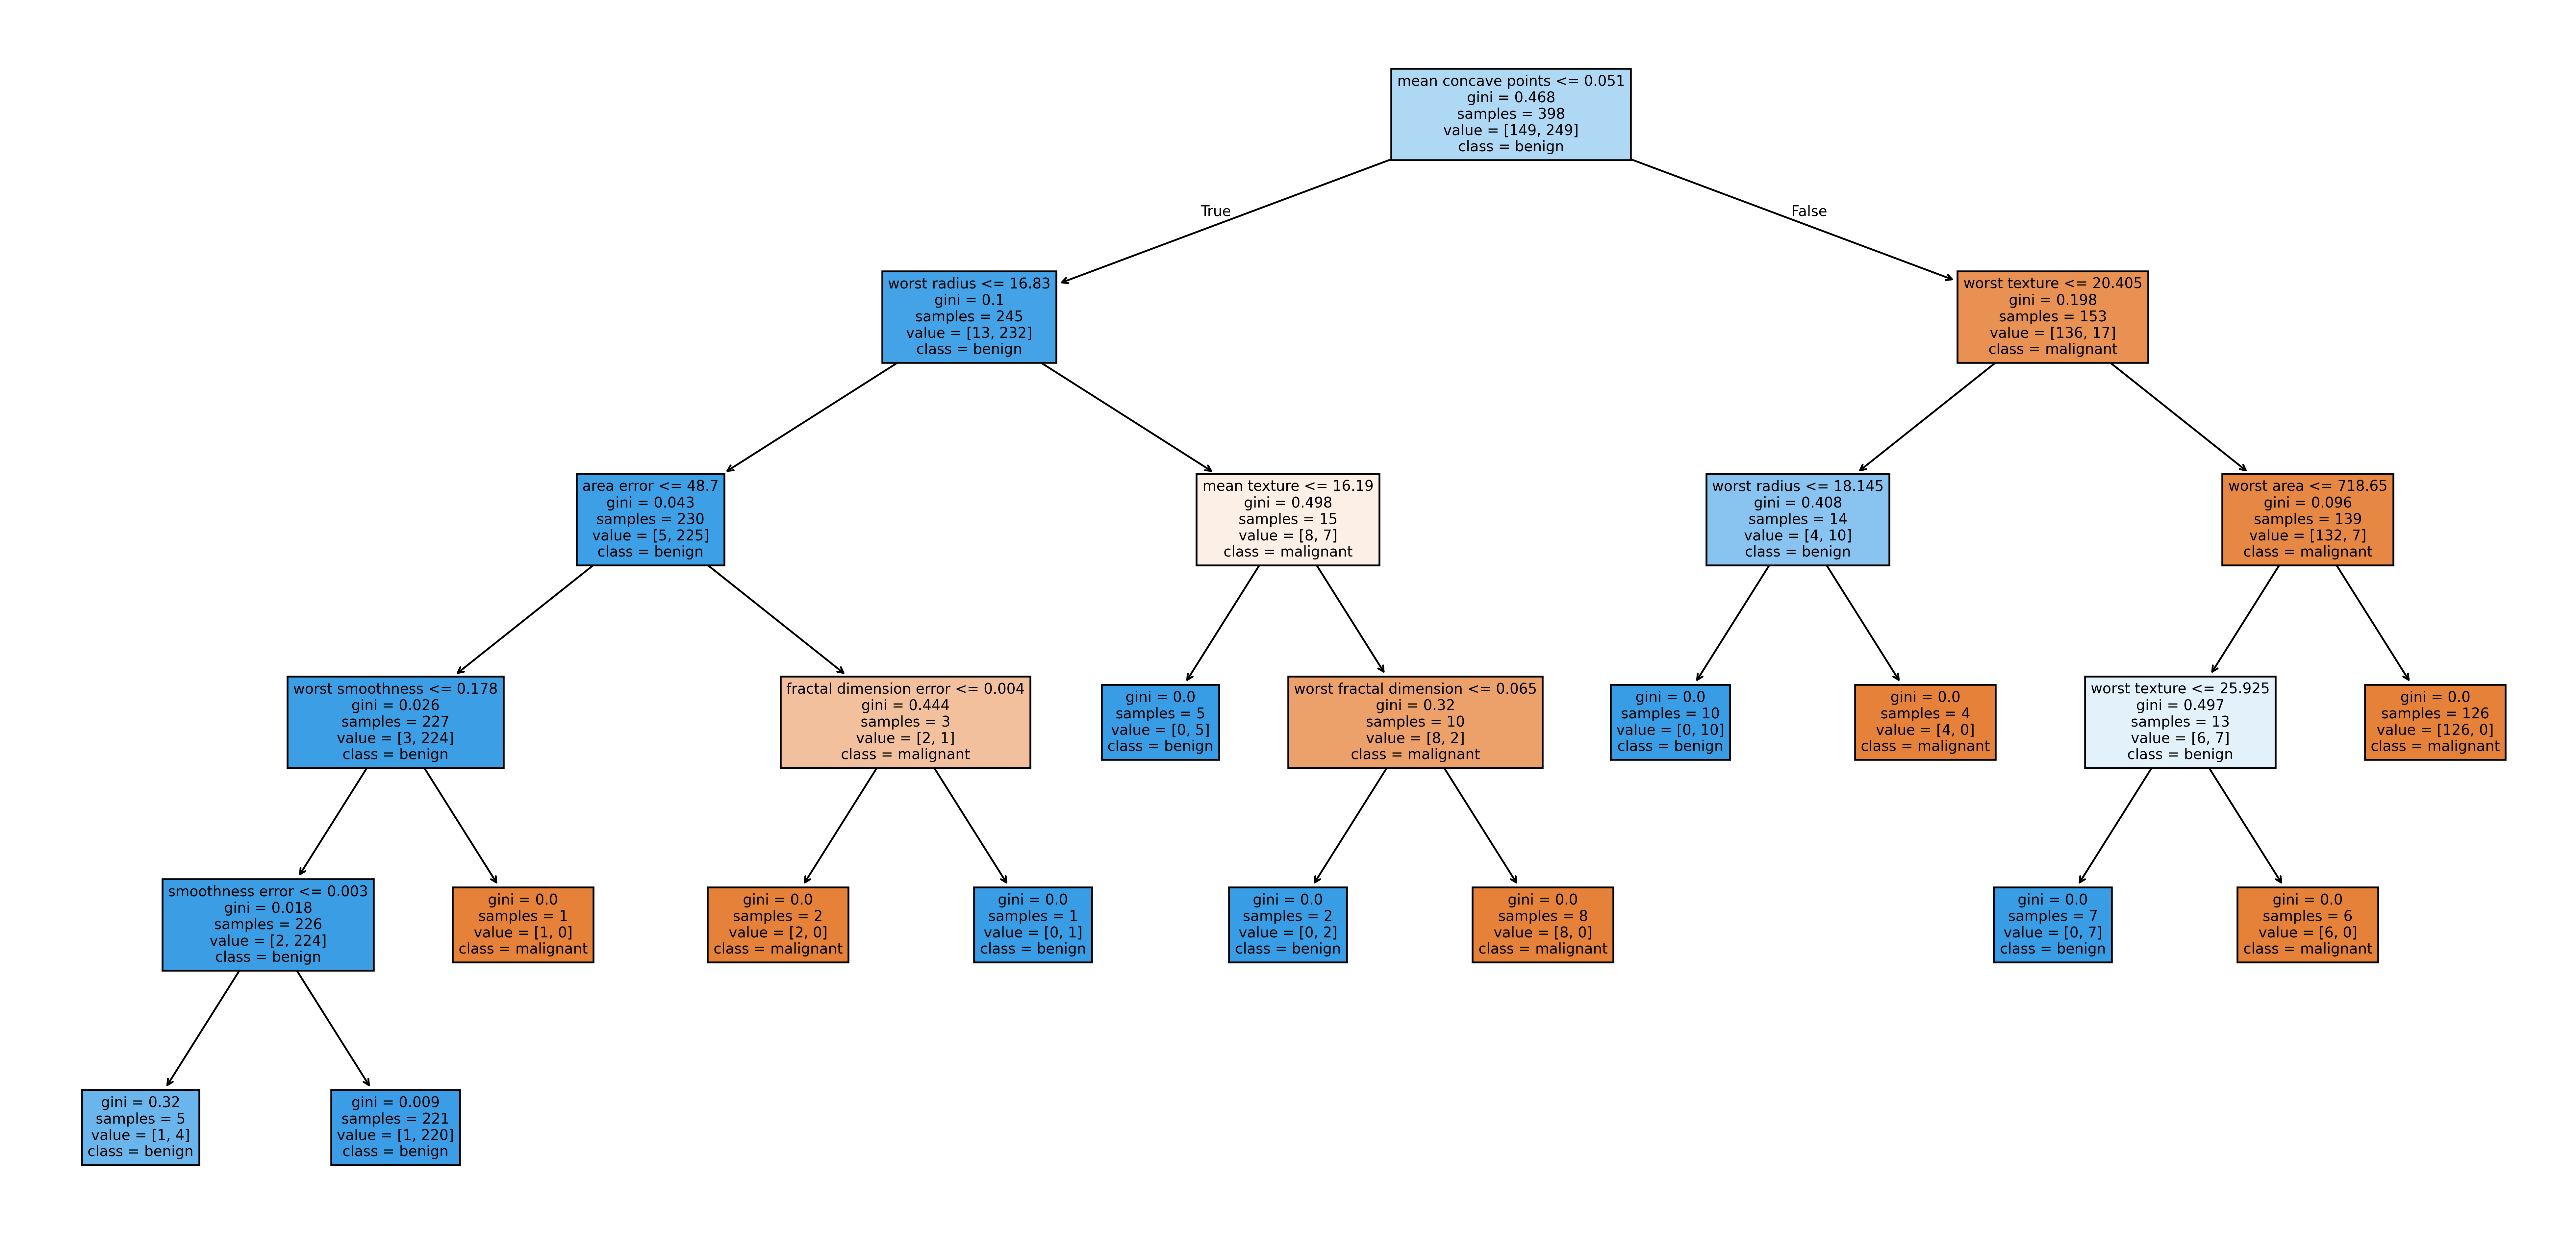

In [42]:
plt.figure(figsize=(25,12), dpi=400)
plot_tree(model, filled=True, feature_names=X.columns, class_names=dataset.target_names)
plt.show();

## Modelos Black Box

In [43]:
from sklearn.ensemble import GradientBoostingClassifier

In [44]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96        63
           1       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



In [45]:
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



In [46]:
import shap

In [47]:
explainer = shap.TreeExplainer(model)

In [48]:
shap_values = explainer.shap_values(X_test)

In [49]:
shap_values

array([[-2.53180779e-02,  2.14224419e-02, -1.00984065e-02, ...,
         1.08754317e+00,  6.52031985e-02, -1.09836075e-03],
       [-3.80261400e-02, -9.39265013e-02, -9.29234524e-03, ...,
        -1.90874502e+00,  5.51587832e-02, -1.14623636e-02],
       [-5.23732967e-02, -4.61781771e-02, -2.11701896e-02, ...,
        -9.23735207e-01,  3.64711565e-02, -6.14785345e-03],
       ...,
       [-2.81712640e-02,  1.99554619e-02, -1.50860158e-02, ...,
         1.08853212e+00,  9.04468732e-02, -1.09836075e-03],
       [ 3.05724997e-03, -2.82210546e-01, -7.74298532e-03, ...,
        -1.87033935e+00, -2.98304348e-01,  1.67448730e-04],
       [-2.81147151e-02,  2.57859412e-01, -1.54752377e-02, ...,
        -1.93907728e+00,  9.43667708e-02, -4.33453266e-04]])

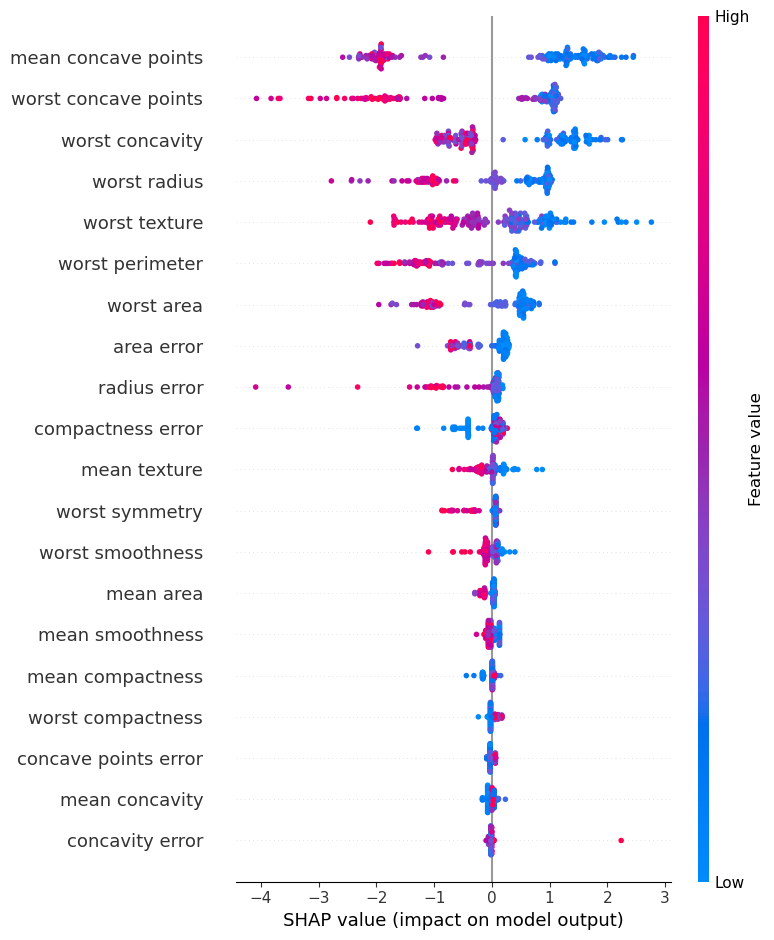

In [50]:
shap.summary_plot(shap_values, X_test)

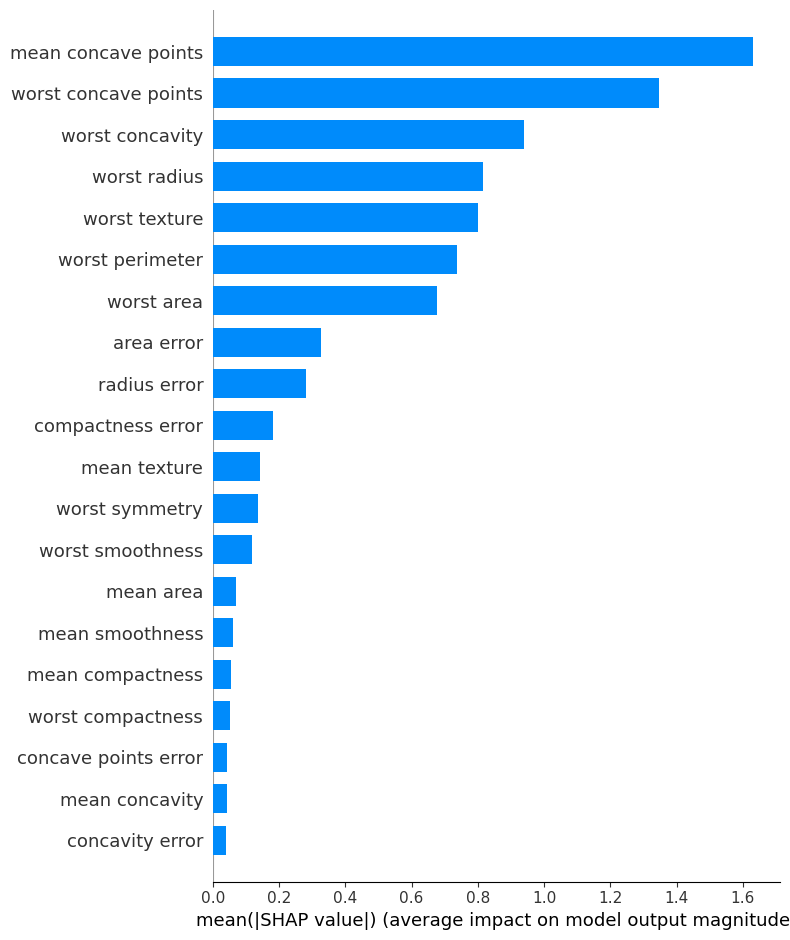

In [51]:
shap.summary_plot(shap_values, X_test, plot_type='bar')